In [49]:
"Initialize"
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import phaseco as pc
import os
import numpy as np
import pandas as pd
from collections import defaultdict


# Directories
dir_otocoh = r"C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence"
dir_phase_coh = r"C:\Users\setht\Dropbox\Citadel\GitHub\phase_coherence"

# Extra funcs
os.chdir(os.path.join(dir_otocoh, 'scripts'))
from helper_funcs import *
os.chdir(dir_phase_coh)

# Folders
figures_folder = os.path.join(dir_phase_coh, 'plots', 'ARO')
pkl_folder = os.path.join(dir_otocoh, 'pickles', 'soae')
results_folder = os.path.join(dir_otocoh, "results", "soae")
tau_pkl_folder = os.path.join(dir_otocoh, 'pickles')

# Make figures folder
os.makedirs(figures_folder, exist_ok=True)

# Colors
human_color = "#8C60B3"
anole_color = "#07586E"

# Plot Equations
dpi = 500


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
"Preparation"
# Switches
show_plot = 1
save_fig = 1

# Plotting params
alpha_static = 0.5
# strokecolor_stat = 'black'
strokecolor_dyn = 'black'
s = 50
s_stroke = s*1.2


# Globals
nfft = 2**14
win_type = "flattop"
species_bws = {"Anole": 150, "Human": 50, "Owl": 300, "Tokay": 150}
markers = {
    "Anole": ("limegreen", "o"),
    "Owl": ("orange", "d"),
    "Human": ("blue", "x"),
    "Tokay": ("green", "+"),
}
mse_thresh = 0.001
xmin = 0.5
xmax = 12
ymin = 1
ymax = 2e3

# Define our methods
static_meth = {
    "win_meth": {"method": "static", "win_type": win_type},
    "hop_thing": ("int", 1),
    "bw_type": "species",
    "mode":'phi'
}

dynamic_meth = {
    "win_meth": {"method": "rho", "win_type": win_type, "rho": 1.0},
    "hop_thing": ("s", 0.01),
    "bw_type": 50,
    "mode":'phi'
}

# Excluded fits for terrible PSD HWHM fits
excluded_fits = [
    (
        "Owl",
        1,
        9258,
    ),
    ("Owl", 0, 4351),
    ("Anole", 3, 2783),
    ("Anole", 2, 1811),
]


# Define helper func to handle legend labels
def get_label_from_firsts(firsts, species):
    if firsts[species]:
        label = f"{species}"
        firsts[species] = 0
    else:
        label = None
    return label, firsts


# First, we gather everything from the two dataframes
N_xis = {}
T_xis = {}
freqs = {}
speciess = {}
titles = {}
mses = {}
wf_idxs = {}
hwhms = []
for method, regime in zip([static_meth, dynamic_meth], ["static", "dynamic"]):
    # Define strings
    bw_str = (
        f"BW=Species" if method["bw_type"] == "species" else f"BW={method['bw_type']}Hz"
    )
    win_meth_str = pc.get_win_meth_str(method["win_meth"])
    relevant_comp_str = rf"{win_meth_str}, {bw_str}, Mode={method['mode']}"
    # Define paths
    specific_results_folder = os.path.join(
        results_folder, rf"SOAE Results ({relevant_comp_str})"
    )
    N_xi_fitted_parameters_fp = os.path.join(
        specific_results_folder, rf"SOAE N_xi Fitted Parameters ({relevant_comp_str}).xlsx"
    )
    # Read df
    df = pd.read_excel(N_xi_fitted_parameters_fp)
    # Gather in lists
    wf_idxs[regime] = df["WF Index"]
    N_xis[regime] = df["N_xi"]
    T_xis[regime] = df["T_xi"]
    freqs[regime] = df["Frequency"]
    speciess[regime] = df["Species"]
    titles[regime] = f"Mode={method['mode']}, {bw_str}, {win_meth_str}"
    mses[regime] = df["MSE"]
    # Only the statics had a corresponding HWHM fit 
    if regime == "static":
        hwhms = df["L_gamma"]



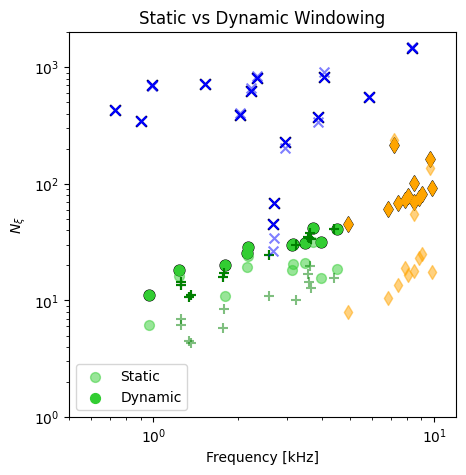

In [51]:
"Static vs dynamic windowing"

plt.close("all")
plt.figure(figsize=(5, 5))
plt.title(f"Static vs Dynamic Windowing")
fn = "static_vs_dynamic.jpg"
# firsts = {"Anole": 1, "Owl": 0, "Human": 0, "Tokay": 0}
for k in range(len(N_xis["static"])):
    species, freq, mse_static, wf_idx = (
        speciess["static"][k],
        freqs["static"][k],
        mses["static"][k],
        wf_idxs["static"][k],
    )
    # Skip egregious static (autocorrelation decay) fits
    if mse_static > mse_thresh or (species, wf_idx, int(round(freq))) in excluded_fits:
        continue

    # Get N_xis
    N_xi_dyn = N_xis["dynamic"][k]
    N_xi_stat = N_xis["static"][k]

    # label, firsts = get_label_from_firsts(firsts, species)
    if species == 'Anole' and k==0:
        label_stat = 'Static'
        label_dyn = 'Dynamic'
    else:
        label_stat = None
        label_dyn = None

    # # Plot line between them
    # plt.vlines(
    #     freq / 1000,
    #     ymin=min(N_xi_stat, N_xi_dyn),
    #     ymax=max(N_xi_stat, N_xi_dyn),
    #     lw=1,
    #     color="k",
    #     zorder=0,
    # )

    # Plot each method

    # Static
    plt.scatter(
        freq / 1000,
        N_xi_stat,
        alpha=alpha_static,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        s=s,
        label=label_stat,
    )
    # plt.scatter(
    #     freq / 1000,
    #     N_xi_stat,
    #     alpha=0.5,
    #     color=strokecolor_stat,
    #     marker=markers[species][1],
    #     zorder=1,
    #     s=s_stroke,
    # )

    # Dynamic
    plt.scatter(
        freq / 1000,
        N_xi_dyn,
        label=label_dyn,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        s=s,
    )
    plt.scatter(
        freq / 1000,
        N_xi_dyn,
        color=strokecolor_dyn,
        marker=markers[species][1],
        zorder=1,
        s=s_stroke
    )
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.loglog()
    plt.legend(loc='lower left')
    # plt.grid(which="both")
    plt.xlabel("Frequency [kHz]")
    plt.ylabel(r"$N_\xi$")



if save_fig:
    fig_fp = os.path.join(figures_folder, fn)
    plt.savefig(fig_fp, dpi=dpi)

if show_plot:
    plt.show()


In [ ]:

"Plot HWHM vs T_xi (static)"

for version in [0, 1, 2]:
    match version:
        case 0:
            regime = 'static'
            xscale = 'linear'
            line_fit_overall = False
            line_fit_species = False
            fn_plot = f'HWHM vs T_xi ({regime}, {xscale})'
        case 1:
            regime = 'dynamic'
            xscale = 'linear'
            line_fit_overall = False
            line_fit_species = False
            fn_plot = f'HWHM vs T_xi ({regime}, {xscale})'
        case 2:
            regime = 'dynamic'
            xscale = 'log'
            line_fit_overall = False
            line_fit_species = False
            fn_plot = f'HWHM vs T_xi ({regime}, {xscale})'
    print(f"Plotting {fn_plot}")
    # Initialize Vars
    firsts = {"Anole": 1, "Owl": 1, "Human": 1, "Tokay": 1}
    hwhms_for_fit = defaultdict(list)
    inv_T_xis_for_fit = defaultdict(list)
    hwhms_for_fit_all = []
    inv_T_xis_for_fit_all = []
    # Initialize plot
    plt.figure(figsize=(5, 5))
    plt.title(rf"$T_\xi$ [{regime.capitalize()} Windowing] vs PSD Peak HWHM")
    for k in range(len(N_xis[regime])):
        wf_idx, species, freq, mse, T_xi, hwhm = (
            wf_idxs[regime][k],
            speciess[regime][k],
            freqs[regime][k],
            mses[regime][k],
            T_xis[regime][k],
            hwhms[k],
        )
        # Skip egregious static fits
        if mse > mse_thresh or (species, wf_idx, int(round(freq))) in excluded_fits:
            print(f"Excluding {species} {wf_idx} {freq:.0f}Hz")
            continue
        # Plot
        label, firsts = get_label_from_firsts(firsts, species)
        plt.scatter(
            hwhm,
            1 / T_xi,
            color=markers[species][0],
            marker=markers[species][1],
            zorder=1,
            label=label,
            s=s,
        )
        plt.legend()
        plt.xlabel(r"PSD HWHM [Hz]")
        plt.ylabel(r"$1/T_\xi$")
        # Add for later
        hwhms_for_fit[species].append(hwhm)
        hwhms_for_fit_all.append(hwhm)
        inv_T_xis_for_fit[species].append(1 / T_xi)
        inv_T_xis_for_fit_all.append(1 / T_xi)

    # Plot per-species line fits
    if line_fit_species:
        for species in speciess[regime].unique():
            p = np.polyfit(hwhms_for_fit[species], inv_T_xis_for_fit[species], 1)  # p[0] = slope, p[1] = intercept
            x = np.linspace(0, max(hwhms_for_fit[species]), 10)
            label = None
            # label = f'y={p[0]:.3g}x + {p[1]:.3g}'
            plt.plot(x, p[0]*x+p[1], label=label, color=markers[species][0], zorder=0)

    # Plot overall line fits
    if line_fit_overall:
        p = np.polyfit(hwhms_for_fit_all, inv_T_xis_for_fit_all, 1)  # p[0] = slope, p[1] = intercept
        x = np.linspace(0, max(hwhms_for_fit_all), 10)
        plt.plot(x, p[0]*x+p[1], label=f'y={p[0]:.3g}x + {p[1]:.3g}')

    plt.xscale(xscale)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(paper_figures_folder, fn_plot), dpi=dpi)


Plotting HWHM vs T_xi (static, linear)
Excluding Anole 1 3023Hz
Excluding Anole 2 1811Hz
Excluding Anole 3 2140Hz
Excluding Anole 3 2417Hz
Excluding Anole 3 2783Hz
Excluding Tokay 0 4211Hz
Excluding Tokay 2 1837Hz
Excluding Tokay 2 2579Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Excluding Owl 2 5626Hz
Excluding Owl 3 5768Hz
Excluding Human 0 2805Hz
Excluding Human 2 1634Hz
Plotting HWHM vs T_xi (dynamic, linear)
Excluding Anole 2 1811Hz
Excluding Anole 3 2783Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Plotting HWHM vs T_xi (dynamic, log)
Excluding Anole 2 1811Hz
Excluding Anole 3 2783Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz


Plotting Dynamic
Excluding Anole 2 1811Hz
Excluding Anole 3 2783Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Plotting Static
Excluding Anole 1 3023Hz
Excluding Anole 2 1811Hz
Excluding Anole 3 2140Hz
Excluding Anole 3 2417Hz
Excluding Anole 3 2783Hz
Excluding Tokay 0 4211Hz
Excluding Tokay 2 1837Hz
Excluding Tokay 2 2579Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Excluding Owl 2 5626Hz
Excluding Owl 3 5768Hz
Excluding Human 0 2805Hz
Excluding Human 2 1634Hz
Plotting Dynamic
Excluding Anole 2 1811Hz
Excluding Anole 3 2783Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Plotting Static
Excluding Anole 1 3023Hz
Excluding Anole 2 1811Hz
Excluding Anole 3 2140Hz
Excluding Anole 3 2417Hz
Excluding Anole 3 2783Hz
Excluding Tokay 0 4211Hz
Excluding Tokay 2 1837Hz
Excluding Tokay 2 2579Hz
Excluding Owl 0 4351Hz
Excluding Owl 1 9258Hz
Excluding Owl 2 5626Hz
Excluding Owl 3 5768Hz
Excluding Human 0 2805Hz
Excluding Human 2 1634Hz
Plotting Dynamic
Excluding Anole 2 1811Hz
Excluding Anole 

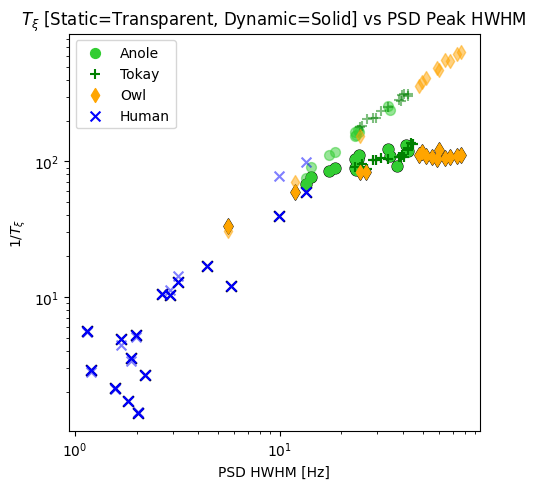

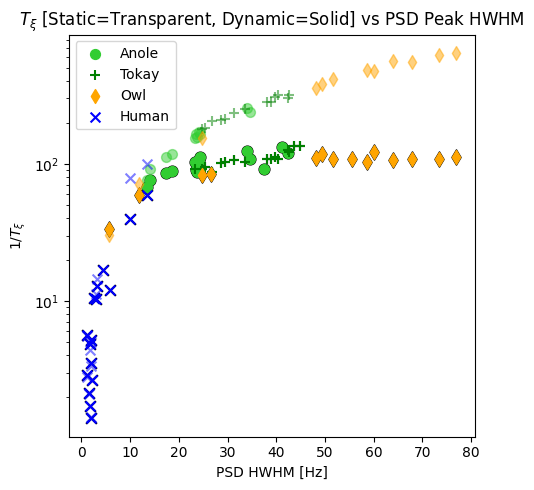

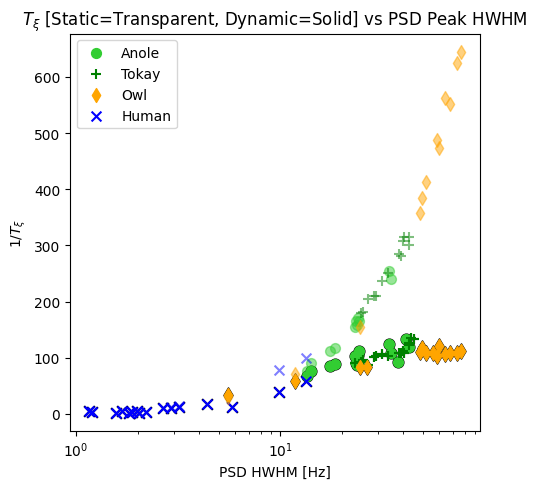

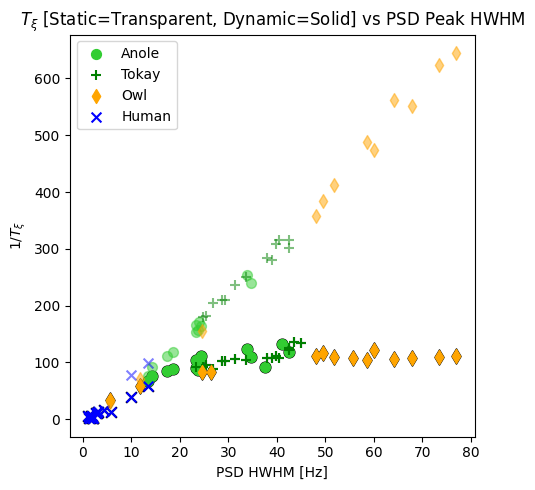

In [ ]:

"Plot HWHM vs T_xi (static AND dynamic)"

for yscale in ['log', 'linear']:
    for xscale in ['log', 'linear']:
        # Initialize plot
        plt.figure(figsize=(5, 5))
        plt.title(rf"$T_\xi$ [Static=Transparent, Dynamic=Solid] vs PSD Peak HWHM")
        fn_plot = f'HWHM vs T_xi (static and dynamic, x={xscale}, y={yscale})'

        # Plotting parameters
        alpha_static = 0.5
        strokecolor_dyn = 'black'
        s = 50
        s_stroke = s*1.2

        # Initialize Vars
        firsts = {"Anole": 1, "Owl": 1, "Human": 1, "Tokay": 1}
        hwhms_for_fit = defaultdict(list)
        inv_T_xis_for_fit = defaultdict(list)
        hwhms_for_fit_all = []
        inv_T_xis_for_fit_all = []

        # Plot Dynamic
        print(f"Plotting Dynamic")
        regime = 'dynamic'
        for k in range(len(N_xis[regime])):
            wf_idx, species, freq, mse, T_xi, hwhm = (
                wf_idxs[regime][k],
                speciess[regime][k],
                freqs[regime][k],
                mses[regime][k],
                T_xis[regime][k],
                hwhms[k],
            )
            # Skip egregious autocorrelation (usually the static ones) OR PSD fits 
            if mse > mse_thresh or (species, wf_idx, int(round(freq))) in excluded_fits:
                print(f"Excluding {species} {wf_idx} {freq:.0f}Hz")
                continue

            # Plot
            label, firsts = get_label_from_firsts(firsts, species)
            plt.scatter(
                hwhm,
                1 / T_xi,
                color=markers[species][0],
                marker=markers[species][1],
                zorder=2,
                label=label,
                s=s,
                alpha=1
            )
            # Plot stroke
            plt.scatter(
                hwhm,
                1 / T_xi,
                color='k',
                marker=markers[species][1],
                zorder=1,
                label=None,
                s=s_stroke,
                alpha=1
            )

        # Plot Static
        print(f"Plotting Static")
        regime = 'static'
        for k in range(len(N_xis[regime])):
            wf_idx, species, freq, mse, T_xi, hwhm = (
                wf_idxs[regime][k],
                speciess[regime][k],
                freqs[regime][k],
                mses[regime][k],
                T_xis[regime][k],
                hwhms[k],
            )
            # Skip egregious autocorrelation (usually the static ones) OR PSD fits 
            if mse > mse_thresh or (species, wf_idx, int(round(freq))) in excluded_fits:
                print(f"Excluding {species} {wf_idx} {freq:.0f}Hz")
                continue

            # Plot
            label = None
            plt.scatter(
                hwhm,
                1 / T_xi,
                color=markers[species][0],
                marker=markers[species][1],
                zorder=3,
                label=label,
                s=s,
                alpha=alpha_static
            )
            

        # Wrap up
        plt.legend()
        plt.xlabel(r"PSD HWHM [Hz]")
        plt.ylabel(r"$1/T_\xi$")
        plt.yscale(yscale)
        plt.xscale(xscale)
        plt.tight_layout()
        plt.savefig(os.path.join(paper_figures_folder, fn_plot), dpi=dpi)


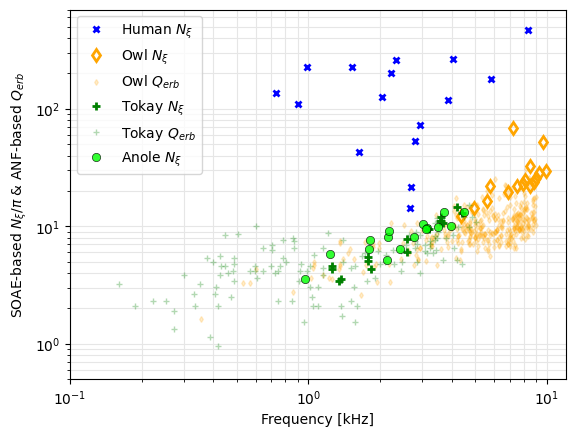

In [ ]:
"Figure 3B"

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
fig_fp = os.path.join(dir_phase_coh, 'Qerb_vs_N_xi.jpg')
fp_N_xi= os.path.join(dir_otocoh, 'results','soae','SOAE Results (rho=1.0, Flattop, BW=50Hz, Mode=phi)', 'SOAE N_xi Fitted Parameters (rho=1.0, Flattop, BW=50Hz, Mode=phi).xlsx')

fact= 1/(np.pi);  # scaling factor for all Nxi {1/pi}

# --- owl ANF tuning curve data (Excel files provided by Christine)
fp_ANFfileOwl= os.path.join(dir_otocoh, 'data','Owl Qerb_analysis_CK2.xlsx')

fp_ANFfileTokay= os.path.join(dir_otocoh, 'data', 'manley99.txt')
# ======================================================


# --- read in data
df = pd.read_excel(fp_N_xi)
owlANF= pd.read_excel(fp_ANFfileOwl)
toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

# ---------
# Get peak frequency and corresponding val to plot
anole_freqs = df[df['Species'] == 'Anole']['Frequency'].values
anole_Nxi = df[df['Species'] == 'Anole']['N_xi'].values
owl_freqs = df[df['Species'] == 'Owl']['Frequency'].values
owl_Nxi = df[df['Species'] == 'Owl']['N_xi'].values
human_freqs = df[df['Species'] == 'Human']['Frequency'].values
human_Nxi = df[df['Species'] == 'Human']['N_xi'].values

tokay_freqs = df[df['Species'] == 'Tokay']['Frequency'].values
tokay_Nxi = df[df['Species'] == 'Tokay']['N_xi'].values


# =========================
# deal w/ owl ANF vals
owlANF= owlANF[1:]  # discard first line
freqANFowl= owlANF['CF'].values
QerbANFowl= owlANF['Qerb'].values

# =========================
# deal w/ tokay ANF vals
freqANFtokay= toakyANFq10[:,0]
QerbANFtokay= 6*toakyANFq10[:,1]*1000/np.pi;  # convert to Qerb(?) via Bergevin & Shera 2010



# =======================================================================
# ==== visualize
plt.close("all")
# ------------------------------------------------
fig1, ax1 = plt.subplots()


# --- human
fig1= plt.plot(human_freqs/1000,human_Nxi*fact,'x',color='blue',
               alpha=1,ms=5,markeredgewidth=2,markerfacecolor='none',label=r'Human $N_{\xi}$')

# --- owl
fig1= plt.plot(owl_freqs/1000,owl_Nxi*fact,'d',color='orange',
               alpha=1.0,ms=6,markeredgewidth=2,markerfacecolor='none',label=r'Owl $N_{\xi}$')

fig1= plt.plot(freqANFowl,QerbANFowl,'d',color='orange',
               alpha=0.2,ms=3,lw=1,markerfacecolor='orange',label=r'Owl $Q_{erb}$')

# --- tokay
fig1= plt.plot(tokay_freqs/1000,tokay_Nxi*fact,'+',color='green',
               alpha=1,ms=6,markeredgewidth=2,markerfacecolor='none',label=r'Tokay $N_{\xi}$')
fig1= plt.plot(freqANFtokay,QerbANFtokay,'+',color='green',
               alpha=0.3,ms=4,lw=1,markerfacecolor='green',label=r'Tokay $Q_{erb}$')

# --- anole
fig1= plt.plot(anole_freqs/1000,anole_Nxi*fact,'o',color='k',markeredgewidth=0.5,
               alpha=0.8,ms=6,markerfacecolor='lime',label=r'Anole $N_{\xi}$')
# ---
ax1.set_xscale('log')
ax1.set_yscale('log')
fig1= plt.xlim([0.1,12])
fig1= plt.ylim([0.5,700])
fig1= plt.xlabel('Frequency [kHz]')
fig1= plt.ylabel(r'SOAE-based $N_{\xi}/\pi$ & ANF-based $Q_{erb}$') 
fig1= plt.grid(True, which="both", ls="-", color='0.9')
fig1= plt.legend()
if (1==0):
    fig1= plt.title('Comparison of Colossogram Time Constants and ANF-derived Tuning') 
plt.savefig(fig_fp, dpi=dpi, bbox_inches='tight')
plt.show()


